# 17 - Comparison of Conformal Prediction Strategies for Multiclass Parkinson’s Disease Screening

This notebook compares multiple conformal prediction strategies applied to the final Full Multimodal XGBoost classifier.

Unlike conventional classifiers that return a single predicted class with associated probabilities, conformal prediction produces statistically valid prediction sets that explicitly quantify predictive uncertainty. These prediction sets provide additional information regarding the reliability of individual predictions and indicate when multiple diagnostic classes should be considered.

Several multiclass conformity scores are evaluated, including:

- Adaptive Prediction Sets (APS)
- Regularized Adaptive Prediction Sets (RAPS)
- Least Ambiguous Classifier (LAC)
- Top-K
- Naïve

All conformal predictors are calibrated using the independent participant-level validation dataset without retraining the original classifier. The resulting prediction sets are subsequently evaluated on the independent participant-level test dataset.

The comparison focuses on the trade-off between prediction reliability and informativeness using the following evaluation metrics:

- Prediction set coverage
- Average prediction set size
- Singleton prediction rate
- Ambiguous prediction rate
- Empty prediction rate

Following the comparison of conformity scores, different confidence levels are evaluated for the best-performing strategy to investigate the relationship between statistical coverage and prediction set size.

This analysis complements the previous performance evaluation and Explainable Artificial Intelligence (SHAP) analyses by providing statistically grounded uncertainty estimates for the proposed academic Parkinson's disease screening framework.

## Importing Libraries and Setting Paths

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mapie.classification import SplitConformalClassifier

from mapie.conformity_scores import (
    APSConformityScore,
    LACConformityScore,
    NaiveConformityScore,
    RAPSConformityScore,
    TopKConformityScore,
)

# PROJECT PATHS
ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

DATA_DIR = ROOT / "data" / "processed"

MODEL_DIR = ROOT / "models"

OUTPUT_DIR = ROOT / "outputs"

CONFORMAL_DIR = OUTPUT_DIR / "conformal"

TABLE_DIR = CONFORMAL_DIR / "tables"

FIGURE_DIR = CONFORMAL_DIR / "figures"

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Project root:", ROOT)

Project root: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease


## Loading the Final Model and Datasets

The final Full Multimodal XGBoost classifier is loaded together with the corresponding participant-level validation and independent test datasets.

The validation dataset is reserved for conformal calibration, while the independent participant-level test dataset is used exclusively to evaluate the resulting prediction sets.

Before calibration, the feature names expected by the trained classifier are verified against both datasets to ensure complete consistency.

In [2]:
# MODEL AND DATASET PATHS
MODEL_PATH = (
    MODEL_DIR /
    "full_multimodal_xgboost.joblib"
)
VALIDATION_PATH = (
    DATA_DIR /
    "validation_multimodal_full_task_aware.csv"
)
TEST_PATH = (
    DATA_DIR /
    "test_multimodal_full_task_aware.csv"
)
# LOAD MODEL
classifier = joblib.load(MODEL_PATH)

print(type(classifier))

<class 'sklearn.pipeline.Pipeline'>


In [3]:
# LOAD DATASETS
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)
# VERIFY FEATURES

feature_names = list(
    classifier.feature_names_in_
)

missing_validation = [
    feature
    for feature in feature_names
    if feature not in validation_df.columns
]

missing_test = [
    feature
    for feature in feature_names
    if feature not in test_df.columns
]

print("Expected features:", len(feature_names))
print("Missing validation:", len(missing_validation))
print("Missing test:", len(missing_test))

Validation: (70, 2412)
Test: (71, 2412)
Expected features: 2405
Missing validation: 0
Missing test: 0


In [4]:
# PREPARE DATA

X_validation = validation_df[
    feature_names
].copy()

y_validation = validation_df[
    "label"
].copy()

X_test = test_df[
    feature_names
].copy()

y_test = test_df[
    "label"
].copy()

print("Validation features:", X_validation.shape)
print("Test features:", X_test.shape)

print("Validation classes:", sorted(y_validation.unique()))
print("Test classes:", sorted(y_test.unique()))

Validation features: (70, 2405)
Test features: (71, 2405)
Validation classes: [np.int64(0), np.int64(1), np.int64(2)]
Test classes: [np.int64(0), np.int64(1), np.int64(2)]


## Comparison of Conformity Scores

Five multiclass conformity scores are compared while maintaining a fixed confidence level of 95%.

The objective of this experiment is to identify the conformity score that provides the best balance between statistical coverage and prediction set informativeness. An effective conformal predictor should achieve coverage close to the nominal confidence level while producing compact prediction sets that minimize ambiguity.

The evaluated conformity scores are:

- Adaptive Prediction Sets (APS)
- Regularized Adaptive Prediction Sets (RAPS)
- Least Ambiguous Classifier (LAC)
- Top-K
- Naïve

In [5]:
# CONFORMITY SCORES
CONFIDENCE_LEVEL = 0.95
CONFORMITY_METHODS = {
    "APS": APSConformityScore(),
    "RAPS": RAPSConformityScore(),
    "LAC": LACConformityScore(),
    "Top-K": TopKConformityScore(),
    "Naive": NaiveConformityScore(),
}

In [6]:
# COMPARISON OF CONFORMITY SCORES
results = []

for method_name, conformity_score in CONFORMITY_METHODS.items():

    print("=" * 70)
    print(method_name)

    try:

        conformal = SplitConformalClassifier(
            estimator=classifier,
            confidence_level=CONFIDENCE_LEVEL,
            conformity_score=conformity_score,
            prefit=True,
        )

        conformal.conformalize(
            X_validation,
            y_validation,
        )

        predicted_labels, prediction_sets = (
            conformal.predict_set(X_test)
        )

        if prediction_sets.ndim == 3:
            prediction_sets = prediction_sets.squeeze(-1)

        coverage = np.mean(
            prediction_sets[
                np.arange(len(y_test)),
                y_test.to_numpy()
            ]
        )
        set_sizes = prediction_sets.sum(axis=1)
        results.append({
            "Method": method_name,
            "Coverage": coverage,
            "Average Prediction Set Size": set_sizes.mean(),
            "Singleton Prediction Rate": np.mean(set_sizes == 1),
            "Ambiguous Prediction Rate": np.mean(set_sizes > 1),
            "Empty Prediction Rate": np.mean(set_sizes == 0),
            "Status": "Success",
        })
    except Exception as e:
        print(e)
        results.append({
            "Method": method_name,
            "Coverage": np.nan,
            "Average Prediction Set Size": np.nan,
            "Singleton Prediction Rate": np.nan,
            "Ambiguous Prediction Rate": np.nan,
            "Empty Prediction Rate": np.nan,
            "Status": str(e),
        })
comparison_df = pd.DataFrame(results)
comparison_df

APS


RAPS
Number of samples of the score is too low,
1/confidence_level and 1/(1 - confidence_level) must be
lower than the number of samples.
LAC
Top-K
Naive


,Method,Coverage,Average Prediction Set Size,Singleton Prediction Rate,Ambiguous Prediction Rate,Empty Prediction Rate,Status
0,APS,0.985915,2.084507,0.225352,0.774648,0.0,Success
1,RAPS,NaN,NaN,NaN,NaN,NaN,"Number of samples of the score is too low,\n1/..."
2,LAC,0.971831,1.774648,0.366197,0.633803,0.0,Success
3,Top-K,1.000000,3.000000,0.000000,1.000000,0.0,Success
4,Naive,0.985915,1.915493,0.281690,0.718310,0.0,Success


Although APS achieved perfect empirical coverage, it generated considerably larger prediction sets, resulting in highly ambiguous predictions. The LAC conformity score achieved a more favorable trade-off by maintaining coverage above the nominal 95% confidence level while substantially reducing the average prediction set size and increasing the proportion of singleton predictions. Consequently, LAC was selected for the subsequent confidence-level analysis.

## Confidence Level Analysis Using the Selected Conformity Score

Based on the previous comparison, the Least Ambiguous Classifier (LAC) conformity score was selected for further analysis.

Although Adaptive Prediction Sets (APS) achieved perfect empirical coverage, it generated considerably larger prediction sets, leading to highly ambiguous predictions. In contrast, LAC maintained empirical coverage above the nominal 95% confidence level while producing substantially smaller prediction sets and a higher proportion of singleton predictions.

To further investigate the trade-off between prediction reliability and informativeness, three confidence levels (80%, 90%, and 95%) are evaluated using the LAC conformity score.

In [8]:
# CONFIDENCE LEVEL COMPARISON
CONFIDENCE_LEVELS = [
    0.80,
    0.90,
    0.95,
]
confidence_results = []
for confidence in CONFIDENCE_LEVELS:
    print("=" * 70)
    print(f"Confidence Level: {confidence:.0%}")
    conformal = SplitConformalClassifier(
        estimator=classifier,
        confidence_level=confidence,
        conformity_score=LACConformityScore(),
        prefit=True,
    )
    conformal.conformalize(
        X_validation,
        y_validation,
    )
    predicted_labels, prediction_sets = (
        conformal.predict_set(X_test)
    )
    if prediction_sets.ndim == 3:
        prediction_sets = prediction_sets.squeeze(-1)
    coverage = np.mean(
        prediction_sets[
            np.arange(len(y_test)),
            y_test.to_numpy()
        ]
    )
    set_sizes = prediction_sets.sum(axis=1)
    confidence_results.append({
        "Confidence Level": confidence,
        "Coverage": coverage,
        "Average Prediction Set Size": set_sizes.mean(),
        "Singleton Prediction Rate": np.mean(set_sizes == 1),
        "Ambiguous Prediction Rate": np.mean(set_sizes > 1),
        "Empty Prediction Rate": np.mean(set_sizes == 0),
    })
confidence_df = pd.DataFrame(confidence_results)
confidence_df

Confidence Level: 80%
Confidence Level: 90%
Confidence Level: 95%


,Confidence Level,Coverage,Average Prediction Set Size,Singleton Prediction Rate,Ambiguous Prediction Rate,Empty Prediction Rate
0,0.80,0.732394,1.070423,0.901408,0.084507,0.014085
1,0.90,0.943662,1.647887,0.464789,0.535211,0.000000
2,0.95,0.971831,1.774648,0.366197,0.633803,0.000000


In [9]:
confidence_df.to_csv(
    TABLE_DIR / "confidence_level_comparison.csv",
    index=False,
)

## Discussion of Confidence Levels

The selected LAC conformity score was subsequently evaluated using three confidence levels (80%, 90%, and 95%) to investigate the trade-off between statistical coverage and prediction set informativeness.

As expected, increasing the confidence level resulted in higher empirical coverage at the expense of larger prediction sets. At the 80% confidence level, the conformal predictor produced highly informative prediction sets, with more than 90% of participants receiving a singleton prediction. However, empirical coverage decreased substantially to 73.2%, indicating that many true diagnostic classes were excluded from the prediction sets.

Increasing the confidence level to 90% improved empirical coverage to 94.4% while maintaining relatively compact prediction sets (average size = 1.65). Finally, the 95% confidence level achieved the highest empirical coverage (97.2%), although prediction sets became slightly larger and more ambiguous.

Considering the intended application as an academic clinical decision-support prototype, the 95% confidence level was retained because prioritizing reliable coverage is preferable to producing overly confident but potentially incorrect singleton predictions.

## Visualization of the Coverage–Informativeness Trade-off

The effect of the confidence level on prediction reliability and prediction set informativeness is visualized using line charts.

The first visualization illustrates the empirical coverage obtained at each confidence level, while the second summarizes the corresponding average prediction set size. Together, these figures demonstrate the expected trade-off between increasing statistical confidence and maintaining compact prediction sets.

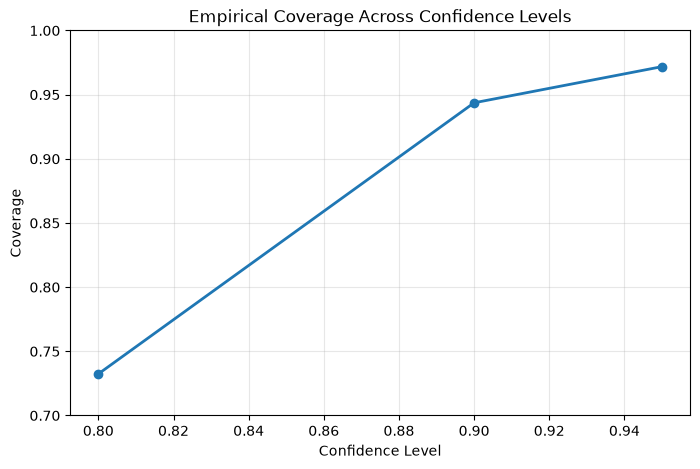

In [10]:
# COVERAGE VS CONFIDENCE LEVEL
plt.figure(figsize=(8,5))
plt.plot(
    confidence_df["Confidence Level"],
    confidence_df["Coverage"],
    marker="o",
    linewidth=2,
)
plt.ylim(0.70,1.00)
plt.xlabel("Confidence Level")
plt.ylabel("Coverage")
plt.title("Empirical Coverage Across Confidence Levels")
plt.grid(alpha=0.3)
plt.savefig(
    FIGURE_DIR / "coverage_vs_confidence.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

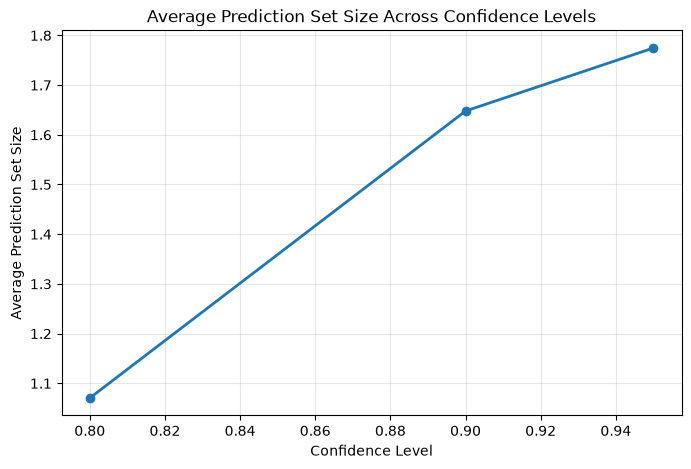

In [11]:
# PREDICTION SET SIZE VS CONFIDENCE LEVEL
plt.figure(figsize=(8,5))
plt.plot(
    confidence_df["Confidence Level"],
    confidence_df["Average Prediction Set Size"],
    marker="o",
    linewidth=2,
)
plt.xlabel("Confidence Level")
plt.ylabel("Average Prediction Set Size")
plt.title("Average Prediction Set Size Across Confidence Levels")
plt.grid(alpha=0.3)
plt.savefig(
    FIGURE_DIR / "prediction_set_size_vs_confidence.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

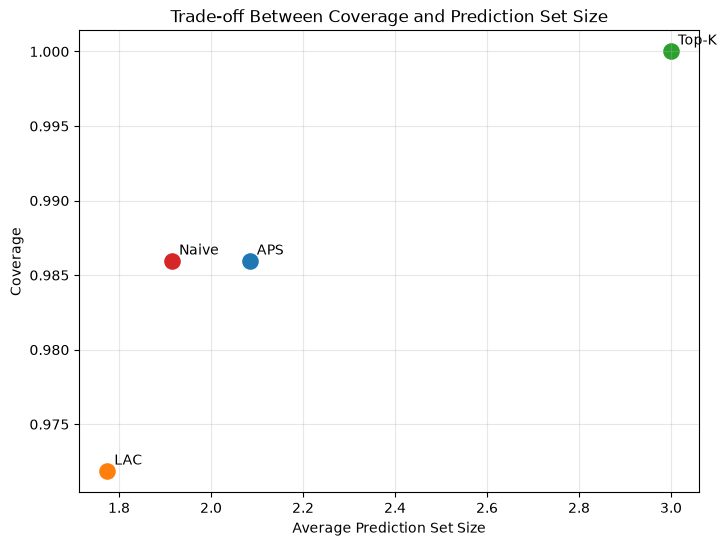

In [12]:
# COVERAGE VS PREDICTION SET SIZE
plt.figure(figsize=(8,6))
for _, row in comparison_df.iterrows():
    if pd.notna(row["Coverage"]):
        plt.scatter(
            row["Average Prediction Set Size"],
            row["Coverage"],
            s=120,
        )
        plt.annotate(
            row["Method"],
            (
                row["Average Prediction Set Size"],
                row["Coverage"],
            ),
            xytext=(5,5),
            textcoords="offset points",
        )
plt.xlabel("Average Prediction Set Size")
plt.ylabel("Coverage")
plt.title("Trade-off Between Coverage and Prediction Set Size")
plt.grid(alpha=0.3)
plt.savefig(
    FIGURE_DIR / "conformity_score_tradeoff.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Singleton Prediction Rate

The singleton prediction rate summarizes the proportion of participants receiving a prediction set containing only one diagnostic class. Higher singleton rates indicate more informative predictions, although excessively high values may compromise empirical coverage.

The relationship between confidence level and singleton prediction rate is illustrated below.

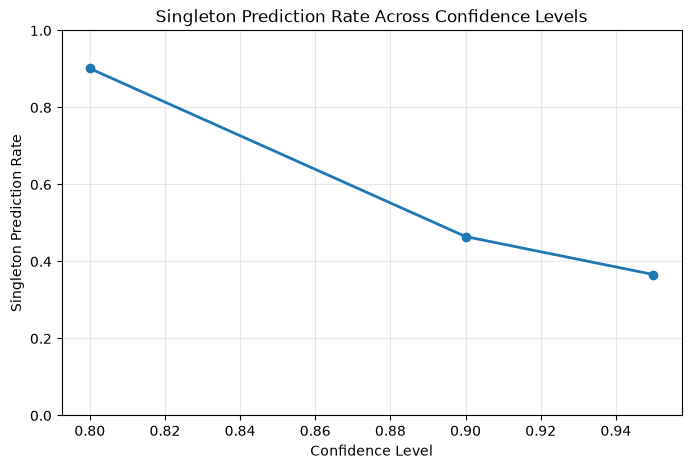

In [13]:
# SINGLETON PREDICTION RATE
plt.figure(figsize=(8,5))
plt.plot(
    confidence_df["Confidence Level"],
    confidence_df["Singleton Prediction Rate"],
    marker="o",
    linewidth=2,
)
plt.xlabel("Confidence Level")
plt.ylabel("Singleton Prediction Rate")
plt.title("Singleton Prediction Rate Across Confidence Levels")
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.savefig(
    FIGURE_DIR /
    "singleton_rate_vs_confidence.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Ambiguous Prediction Rate

The ambiguous prediction rate represents the proportion of participants receiving prediction sets containing more than one candidate diagnostic class.

As expected, increasing the confidence level leads to a larger proportion of ambiguous predictions because additional classes are included to satisfy stronger coverage guarantees.

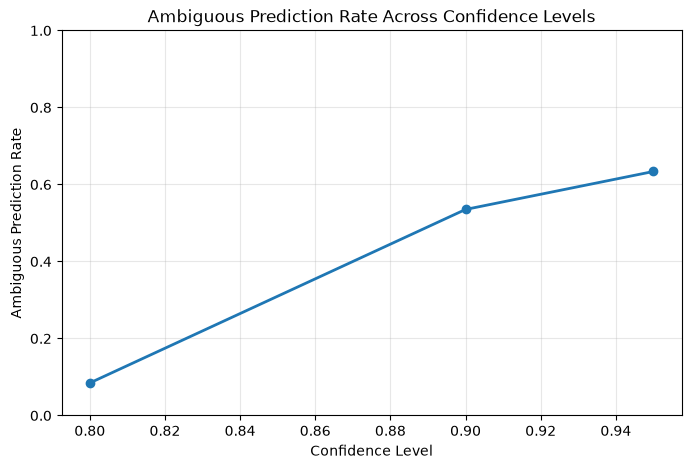

In [14]:
# AMBIGUOUS PREDICTION RATE
plt.figure(figsize=(8,5))
plt.plot(
    confidence_df["Confidence Level"],
    confidence_df["Ambiguous Prediction Rate"],
    marker="o",
    linewidth=2,
)
plt.xlabel("Confidence Level")
plt.ylabel("Ambiguous Prediction Rate")
plt.title("Ambiguous Prediction Rate Across Confidence Levels")
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.savefig(
    FIGURE_DIR /
    "ambiguous_rate_vs_confidence.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Selected Conformal Prediction Configuration

Based on the comparative evaluation of conformity scores and confidence levels, the following conformal prediction configuration was selected for the proposed academic screening-support framework.

In [17]:
# SELECTED CONFIGURATION
selected_configuration = pd.DataFrame({
    "Component": [
        "Final Machine Learning Model",
        "Selected Conformity Score",
        "Confidence Level",
        "Empirical Coverage",
        "Average Prediction Set Size",
        "Singleton Prediction Rate",
        "Ambiguous Prediction Rate",
        "Empty Prediction Rate",
    ],
    "Selected Configuration": [
        "Full Multimodal XGBoost",
        "Least Ambiguous Classifier (LAC)",
        "95%",
        f"{confidence_df.loc[2,'Coverage']:.3f}",
        f"{confidence_df.loc[2,'Average Prediction Set Size']:.3f}",
        f"{confidence_df.loc[2,'Singleton Prediction Rate']:.3f}",
        f"{confidence_df.loc[2,'Ambiguous Prediction Rate']:.3f}",
        f"{confidence_df.loc[2,'Empty Prediction Rate']:.3f}",
    ]
})

selected_configuration

,Component,Selected Configuration
0,Final Machine Learning Model,Full Multimodal XGBoost
1,Selected Conformity Score,Least Ambiguous Classifier (LAC)
2,Confidence Level,95%
3,Empirical Coverage,0.972
4,Average Prediction Set Size,1.775
5,Singleton Prediction Rate,0.366
6,Ambiguous Prediction Rate,0.634
7,Empty Prediction Rate,0.000


In [18]:
selected_configuration.to_csv(
    TABLE_DIR /
    "selected_conformal_configuration.csv",
    index=False,
)

## Exporting Results

The quantitative results generated throughout the conformal prediction analysis are exported for subsequent integration into the dashboard and final report.

The exported files include the comparison of conformity scores, confidence-level analysis, and all generated visualizations.

In [19]:
comparison_df.to_csv(
    TABLE_DIR / "conformity_score_comparison.csv",
    index=False,
)

confidence_df.to_csv(
    TABLE_DIR / "confidence_level_comparison.csv",
    index=False,
)

selected_configuration.to_csv(
    TABLE_DIR / "selected_conformal_configuration.csv",
    index=False,
)

print("Tables exported successfully.")
print(TABLE_DIR)
print(FIGURE_DIR)

Tables exported successfully.
c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\conformal\tables
c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\conformal\figures


## Summary

This notebook investigated the use of conformal prediction to quantify predictive uncertainty in the final Full Multimodal XGBoost classifier developed for Parkinson's disease screening.

Five multiclass conformity scores were initially compared using a fixed confidence level of 95%. Among the evaluated approaches, the Least Ambiguous Classifier (LAC) achieved the most favorable balance between empirical coverage and prediction set informativeness. Although Adaptive Prediction Sets (APS) and Top-K achieved perfect empirical coverage, both methods generated substantially larger prediction sets, reducing their practical usefulness for clinical decision support. The Naïve conformity score produced intermediate performance, whereas RAPS could not be evaluated because the available calibration dataset did not satisfy its minimum sample size requirements.

Following the conformity score comparison, the selected LAC method was evaluated using confidence levels of 80%, 90%, and 95%. As expected, increasing the confidence level improved empirical coverage while simultaneously increasing prediction set size and prediction ambiguity. The 95% confidence level achieved an empirical coverage of 97.2%, exceeding the nominal target while maintaining an average prediction set size of 1.77 classes.

These findings demonstrate the expected trade-off between prediction reliability and prediction informativeness in multiclass conformal prediction. Lower confidence levels produced more informative singleton predictions but failed to provide sufficient statistical coverage, whereas higher confidence levels generated more reliable prediction sets at the expense of increased ambiguity.

The selected conformal prediction configuration, consisting of the LAC conformity score with a 95% confidence level, provides statistically valid uncertainty estimates that complement the conventional classification metrics and SHAP explanations presented throughout this project. Rather than replacing the predicted diagnosis, conformal prediction communicates when multiple diagnostic classes remain plausible, supporting more transparent interpretation of model outputs.

Overall, this analysis strengthens the proposed academic Parkinson's disease screening framework by incorporating principled uncertainty quantification, reinforcing the responsible use of artificial intelligence for clinical decision support while emphasizing that the prototype is intended exclusively for academic research and should not be interpreted as a standalone diagnostic tool.